In [5]:
import os
import random
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import math
from network_funcs import S2_graph_definite_N, plot_graph_on_sphere

# Create directory for saving graphs
output_folder = "saved_graphs"
os.makedirs(output_folder, exist_ok=True)

In [6]:
def classifying_ent_QKD(G):
    """Classifies nodes into edges, repeaters, and switches based on degree."""
    degrees_QKD = dict(G.degree())
    node_size = []
    colors = []

    for node in G.nodes():
        deg = degrees_QKD[node]
        node_size.append(deg)

        if deg == 1:
            colors.append('yellow')
        elif deg == 2:
            colors.append('blue')
        else:
            colors.append('red')

    return node_size, colors

def plot_and_save(G, title, filename):
    """Plots graph using Kamada-Kawai layout and saves to folder."""
    node_size, colors = classifying_ent_QKD(G)

    # Scale sizes for visibility
    scaled_sizes = [10 + (15 * math.log(max(1, s))) for s in node_size]

    # Use Kamada-Kawai layout for all representations
    pos = nx.kamada_kawai_layout(G)

    plt.figure(figsize=(10, 8))
    nx.draw_networkx_nodes(G, pos, node_size=scaled_sizes, node_color=colors, edgecolors='black', linewidths=0.5)
    nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color='gray')

    plt.title(title)
    plt.axis('off')

    filepath = os.path.join(output_folder, filename)
    plt.savefig(filepath, format="pdf", bbox_inches='tight', facecolor='white', transparent=False)
    plt.show()

In [15]:
def inject_repeater_chains(G, hub_threshold=4, min_rep=2, max_rep=4, skip_prob=0.1):
    next_node_id = max(G.nodes()) + 1

    for u, v in list(G.edges()):
        if G.degree(u) >= hub_threshold and G.degree(v) >= hub_threshold:
            if random.random() < skip_prob:
                continue

            G.remove_edge(u, v)
            num_repeaters = random.randint(min_rep, max_rep)
            prev_node = u

            for _ in range(num_repeaters):
                G.add_node(next_node_id, type='repeater')
                G.add_edge(prev_node, next_node_id)
                prev_node = next_node_id
                next_node_id += 1

            G.add_edge(prev_node, v)
    return G

def generate_exact_injected_dual_ba(target_nodes=500):
    """
    Guarantees an exactly sized Injected Dual-BA graph by generating a smaller core,
    injecting repeaters, and topping off the remainder with end-users.
    """
    # Start with a safe smaller core (80% of target)
    core_size = int(target_nodes * 0.80)
    G_dba = nx.dual_barabasi_albert_graph(core_size, m1=5, m2=1, p=0.05)

    # Inject the repeaters
    G_idba = inject_repeater_chains(G_dba, hub_threshold=4, min_rep=1, max_rep=3, skip_prob=0.2)

    # Top off the graph to exactly `target_nodes` using Preferential Attachment
    hubs = [n for n in G_idba.nodes() if G_idba.degree(n) >= 4]
    hub_degrees = [G_idba.degree(n) for n in hubs]

    next_node_id = max(G_idba.nodes()) + 1

    while G_idba.number_of_nodes() < target_nodes:
        # Pick a hub based on degree weight
        chosen_hub = random.choices(hubs, weights=hub_degrees, k=1)[0]

        # Add the end user
        G_idba.add_node(next_node_id, type='end')
        G_idba.add_edge(chosen_hub, next_node_id)

        # Update weights and IDs
        hub_degrees[hubs.index(chosen_hub)] += 1
        next_node_id += 1

    return G_idba

def add_end_users_to_s2(G_s2, original_coords, num_end_users):
    G = G_s2.copy()
    hubs = list(G.nodes())
    hub_degrees = [G.degree(n) for n in hubs]
    next_node_id = len(hubs)

    for _ in range(num_end_users):
        chosen_hub = random.choices(hubs, weights=hub_degrees, k=1)[0]
        G.add_node(next_node_id, type='end')
        G.add_edge(chosen_hub, next_node_id)
        hub_degrees[chosen_hub] += 1
        next_node_id += 1

    return G

def build_scalable_backbone(total_nodes, switch_percentage=0.08):
    num_switches = int(total_nodes * switch_percentage)
    backbone = nx.watts_strogatz_graph(n=num_switches, k=4, p=0.2)
    next_node_id = num_switches

    for u, v in list(backbone.edges()):
        backbone.remove_edge(u, v)
        num_repeaters = random.randint(1, 3)
        prev_node = u

        for _ in range(num_repeaters):
            backbone.add_node(next_node_id, type='repeater')
            backbone.add_edge(prev_node, next_node_id)
            prev_node = next_node_id
            next_node_id += 1

        backbone.add_edge(prev_node, v)
    return backbone

def spatial_preferential_attachment(n, m=2, alpha=2.5, map_size=1000):
    G = nx.Graph()
    coords = {i: (random.uniform(0, map_size), random.uniform(0, map_size)) for i in range(n)}

    for i in range(3):
        G.add_node(i, pos=coords[i])
    G.add_edges_from([(0, 1), (1, 2), (2, 0)])

    for i in range(3, n):
        G.add_node(i, pos=coords[i])
        existing_nodes = list(G.nodes())[:-1]
        weights = []

        for j in existing_nodes:
            dist = np.sqrt((coords[i][0] - coords[j][0])**2 + (coords[i][1] - coords[j][1])**2)
            dist = max(dist, 0.001)
            score = G.degree(j) / (dist ** alpha)
            weights.append(score)

        chosen_targets = set()
        while len(chosen_targets) < m:
            target = random.choices(existing_nodes, weights=weights, k=1)[0]
            chosen_targets.add(target)

        for target in chosen_targets:
            G.add_edge(i, target)

    return G

In [16]:
total_nodes = 100
graphs_dict = {}

# Barabasi-Albert
G_ba = nx.barabasi_albert_graph(total_nodes, 1)
graphs_dict['Barabasi-Albert'] = G_ba

# Dual Barabasi-Albert
G_dba = nx.dual_barabasi_albert_graph(total_nodes, m1=5, m2=1, p=0.05)
graphs_dict['Dual Barabasi-Albert'] = G_dba

# Injected Dual-Barabasi-Albert
G_idba = generate_exact_injected_dual_ba(target_nodes=total_nodes)
graphs_dict['Injected Dual-BA'] = G_idba

# Extended Barabasi-Albert
G_eba = nx.extended_barabasi_albert_graph(total_nodes, m=1, p=0.1, q=0.1)
graphs_dict['Extended Barabasi-Albert'] = G_eba

# Lucas S2 model
A_s2, _, s2_coords = S2_graph_definite_N(total_nodes, beta=2.6, mu=0.0233, return_coords=True)
G_s2 = nx.from_numpy_array(A_s2)
graphs_dict['Lucas S2'] = G_s2

# Lucas S2 model with added end users
n_core = int(0.8*total_nodes)
A_s2_core, _, s2_coords_core = S2_graph_definite_N(n_core, beta=2.6, mu=0.0233, return_coords=True)
G_s2_core = nx.from_numpy_array(A_s2_core)
G_s2_users = add_end_users_to_s2(G_s2_core, s2_coords_core, num_end_users=total_nodes-n_core)
graphs_dict['Lucas S2 + End Users'] = G_s2_users

# Backbone + Preferential attachment
G_bb = build_scalable_backbone(total_nodes)
G_bb_pa = nx.barabasi_albert_graph(total_nodes, m=1, initial_graph=G_bb)
graphs_dict['Backbone + PA'] = G_bb_pa

# Spatial Preferential attachment
G_spa = spatial_preferential_attachment(total_nodes, m=1, alpha=2.5)
graphs_dict['Spatial PA'] = G_spa

Plotting Barabasi-Albert...


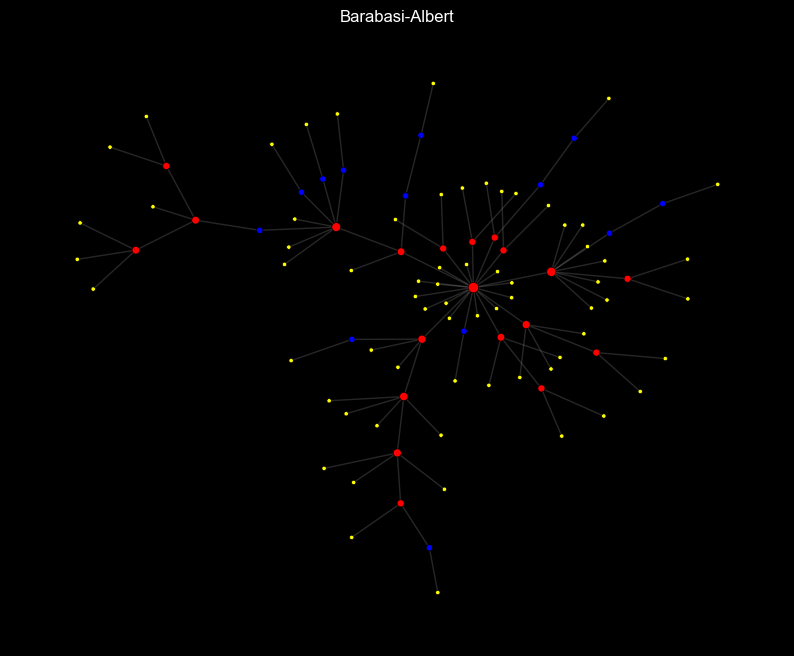

Plotting Dual Barabasi-Albert...


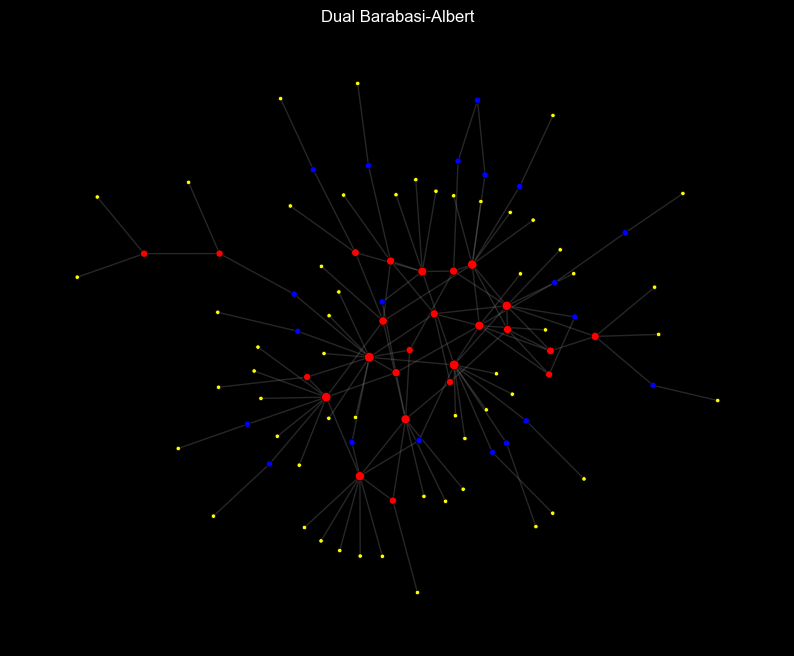

Plotting Injected Dual-BA...


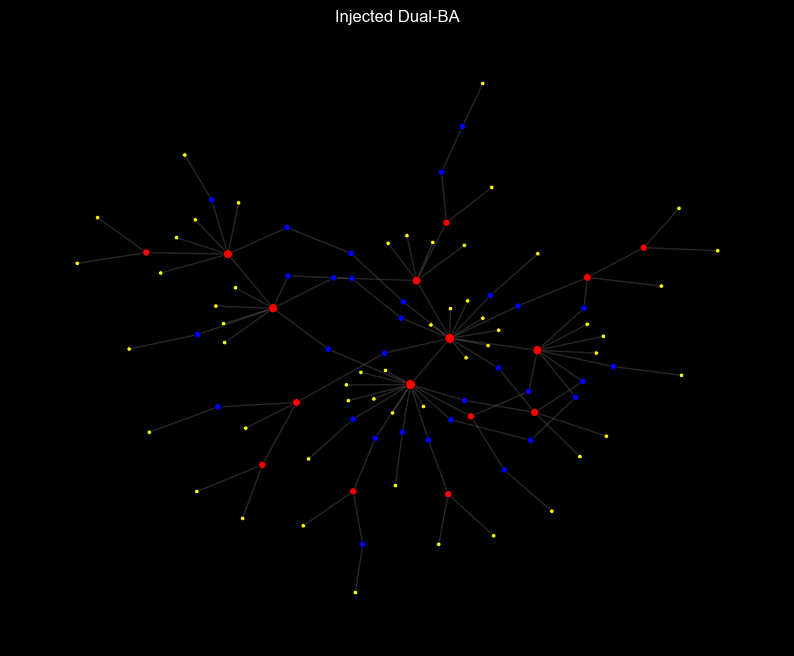

Plotting Extended Barabasi-Albert...


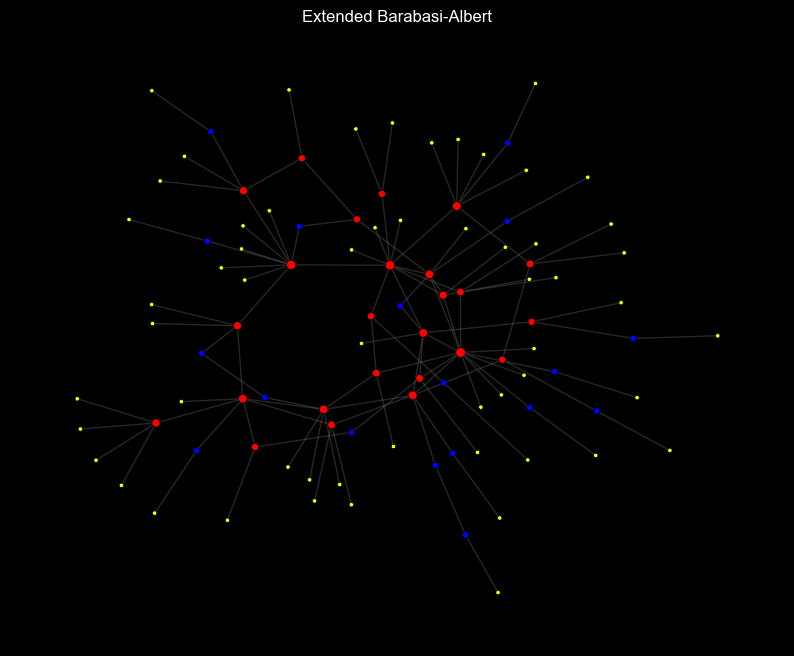

Plotting Lucas S2...


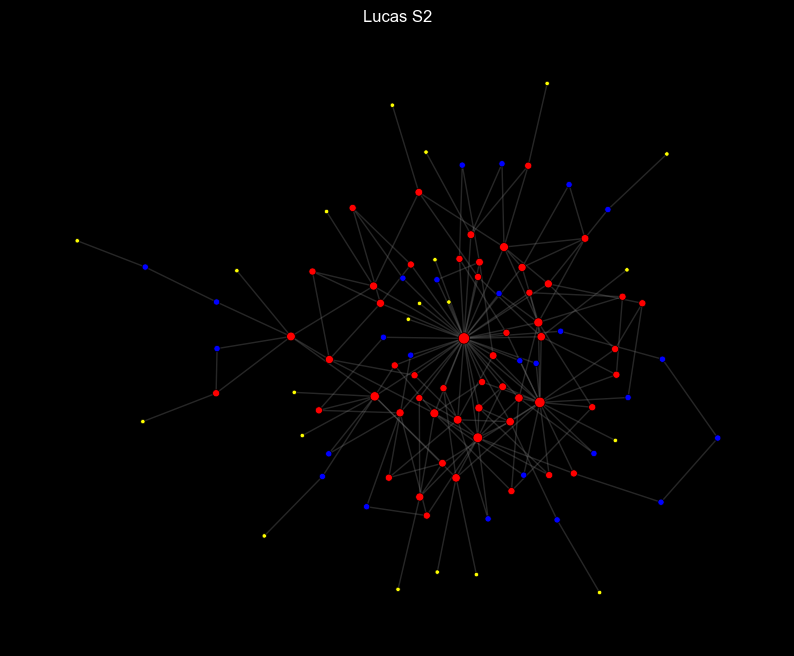

Plotting Lucas S2 + End Users...


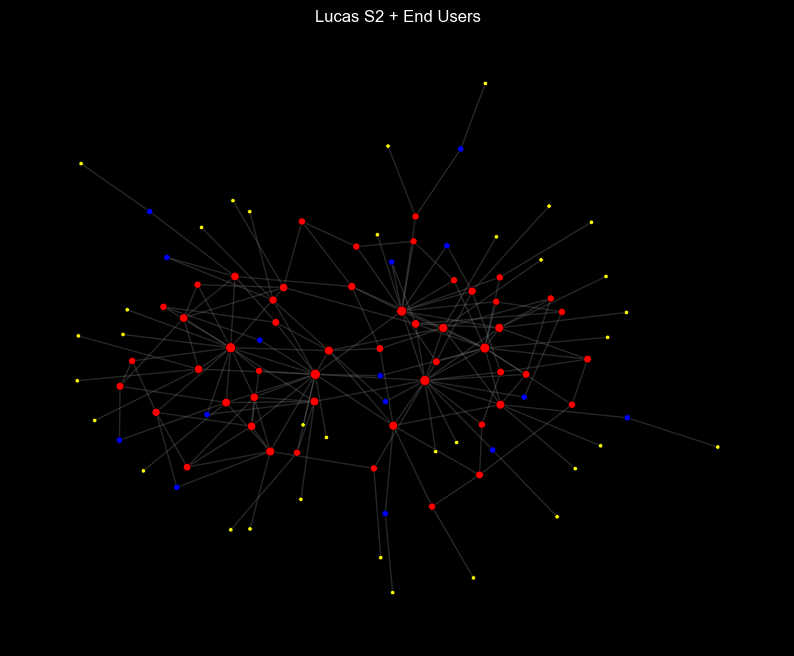

Plotting Backbone + PA...


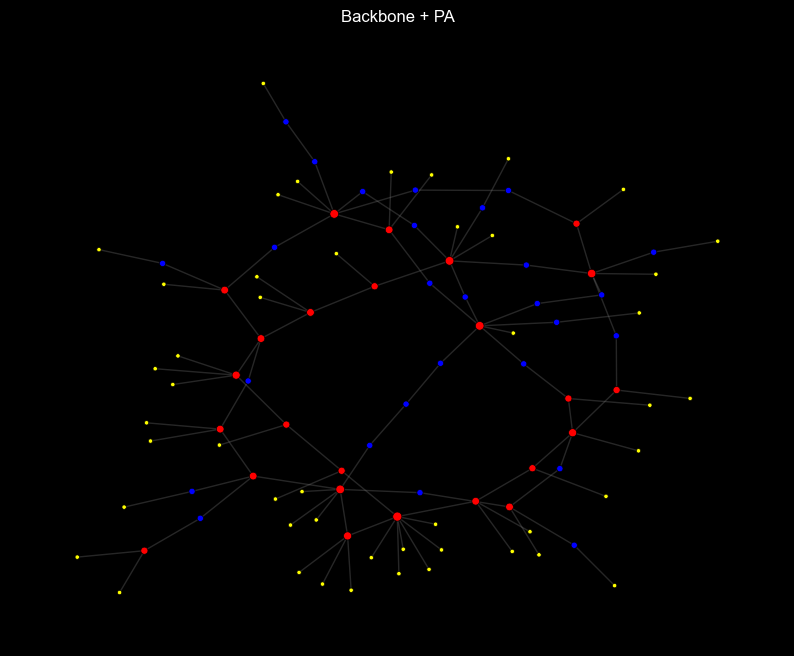

Plotting Spatial PA...


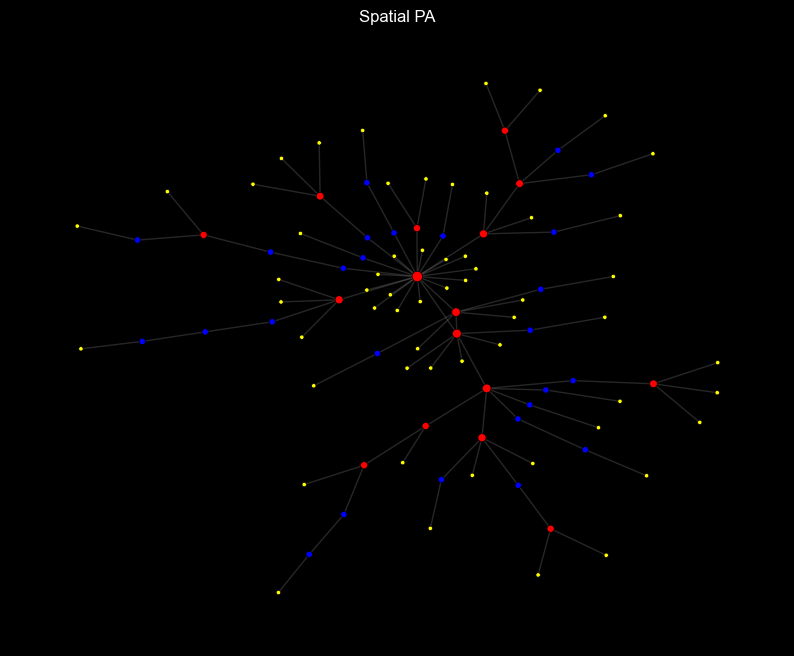

In [17]:
for name, G in graphs_dict.items():
    filename = f"{name.replace(' ', '_').replace('+', 'plus')}.pdf"
    print(f"Plotting {name}...")
    plot_and_save(G, name, filename)

In [18]:
total_nodes = 500
graphs_dict = {}

# Barabasi-Albert
G_ba = nx.barabasi_albert_graph(total_nodes, 1)
graphs_dict['Barabasi-Albert'] = G_ba

# Dual Barabasi-Albert
G_dba = nx.dual_barabasi_albert_graph(total_nodes, m1=5, m2=1, p=0.05)
graphs_dict['Dual Barabasi-Albert'] = G_dba

# Injected Dual-Barabasi-Albert
G_idba = generate_exact_injected_dual_ba(target_nodes=total_nodes)
graphs_dict['Injected Dual-BA'] = G_idba

# Extended Barabasi-Albert
G_eba = nx.extended_barabasi_albert_graph(total_nodes, m=1, p=0.1, q=0.1)
graphs_dict['Extended Barabasi-Albert'] = G_eba

# Lucas S2 model
A_s2, _, s2_coords = S2_graph_definite_N(total_nodes, beta=2.6, mu=0.0233, return_coords=True)
G_s2 = nx.from_numpy_array(A_s2)
graphs_dict['Lucas S2'] = G_s2

# Lucas S2 model with added end users
n_core = int(0.8 * total_nodes)
A_s2_core, _, s2_coords_core = S2_graph_definite_N(n_core, beta=2.6, mu=0.0233, return_coords=True)
G_s2_core = nx.from_numpy_array(A_s2_core)
G_s2_users = add_end_users_to_s2(G_s2_core, s2_coords_core, num_end_users=total_nodes - n_core)
graphs_dict['Lucas S2 + End Users'] = G_s2_users

# Backbone + Preferential attachment
G_bb = build_scalable_backbone(total_nodes)
G_bb_pa = nx.barabasi_albert_graph(total_nodes, m=1, initial_graph=G_bb)
graphs_dict['Backbone + PA'] = G_bb_pa

# Spatial Preferential attachment
# G_spa = spatial_preferential_attachment(total_nodes, m=1, alpha=2.5)
# graphs_dict['Spatial PA'] = G_spa

In [19]:
def compute_metrics(G, name):
    degrees = [d for n, d in G.degree()]
    total = len(degrees)

    ends = sum(1 for d in degrees if d == 1)
    reps = sum(1 for d in degrees if d == 2)
    switches = sum(1 for d in degrees if d > 2)
    switch_degs = [d for d in degrees if d > 2]

    avg_switch_deg = sum(switch_degs) / len(switch_degs) if switch_degs else 0
    avg_deg = sum(degrees) / total

    # Calculate shortest path on giant component
    giant = G.subgraph(max(nx.connected_components(G), key=len))
    avg_sp = nx.average_shortest_path_length(giant)

    avg_clust = nx.average_clustering(G)

    return {
        "Graph Type": name,
        "% End Nodes": (ends / total) * 100,
        "% Repeaters": (reps / total) * 100,
        "% Switches": (switches / total) * 100,
        "Avg Switch Degree": avg_switch_deg,
        "Avg Degree": avg_deg,
        "Avg Shortest Path Length": avg_sp,
        "Clustering Degree": avg_clust
    }

metrics_list = []
for name, G in graphs_dict.items():
    metrics_list.append(compute_metrics(G, name))

df_metrics = pd.DataFrame(metrics_list)

# Round values for clean LaTeX presentation
df_metrics = df_metrics.round(3)

print("DATA FRAME:")
display(df_metrics)

print("\nLATEX CODE FOR OVERLEAF:")
# Convert DataFrame to LaTeX format
latex_code = df_metrics.to_latex(index=False, escape=False, float_format="%.3f")
print(latex_code)

DATA FRAME:


,Graph Type,% End Nodes,% Repeaters,% Switches,Avg Switch Degree,Avg Degree,Avg Shortest Path Length,Clustering Degree
0,Barabasi-Albert,66.600,15.600,17.800,5.719,1.996,6.855,0.000
1,Dual Barabasi-Albert,63.800,13.600,22.600,7.283,2.556,4.533,0.012
2,Injected Dual-BA,45.872,39.266,14.862,6.741,2.246,6.562,0.000
3,Extended Barabasi-Albert,53.600,21.600,24.200,5.405,2.276,5.572,0.005
4,Lucas S2,23.600,28.000,48.400,6.455,3.920,4.038,0.180
5,Lucas S2 + End Users,37.400,20.600,42.000,7.167,3.796,2.545,0.359
6,Backbone + PA,49.600,24.400,26.000,4.523,2.160,10.740,0.000



LATEX CODE FOR OVERLEAF:
\begin{tabular}{lrrrrrrr}
\toprule
Graph Type & % End Nodes & % Repeaters & % Switches & Avg Switch Degree & Avg Degree & Avg Shortest Path Length & Clustering Degree \\
\midrule
Barabasi-Albert & 66.600 & 15.600 & 17.800 & 5.719 & 1.996 & 6.855 & 0.000 \\
Dual Barabasi-Albert & 63.800 & 13.600 & 22.600 & 7.283 & 2.556 & 4.533 & 0.012 \\
Injected Dual-BA & 45.872 & 39.266 & 14.862 & 6.741 & 2.246 & 6.562 & 0.000 \\
Extended Barabasi-Albert & 53.600 & 21.600 & 24.200 & 5.405 & 2.276 & 5.572 & 0.005 \\
Lucas S2 & 23.600 & 28.000 & 48.400 & 6.455 & 3.920 & 4.038 & 0.180 \\
Lucas S2 + End Users & 37.400 & 20.600 & 42.000 & 7.167 & 3.796 & 2.545 & 0.359 \\
Backbone + PA & 49.600 & 24.400 & 26.000 & 4.523 & 2.160 & 10.740 & 0.000 \\
\bottomrule
\end{tabular}

